In [51]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
import warnings
warnings.filterwarnings("ignore")

pd.set_option('display.max_columns',100)
pd.set_option('display.max_rows',100)

plt.style.use('dark_background')

def sample(data, labels, num_samples_per_digit):
    sampled_data = []
    sampled_labels = []
    for digit in range(4):
        digit_indices = np.where(labels == digit)[0]
        sampled_indices = np.random.choice(digit_indices, num_samples_per_digit, replace=False)
        sampled_data.append(data[sampled_indices])
        sampled_labels.append(labels[sampled_indices])
    return np.concatenate(sampled_data), np.concatenate(sampled_labels)

# Load / resize images

In [52]:
from tensorflow.keras.datasets import cifar10

# Load data
(X_train, y_train), (X_test, y_test) = cifar10.load_data()

# Define how many samples of each digit to include
train_samples_per_class = 1000
test_samples_per_class = 200

# Sample the training and testing data
X_train, y_train = sample(X_train, y_train, train_samples_per_class)
X_test, y_test = sample(X_test, y_test, test_samples_per_class)

# Print shapes
print("X_train.shape:", X_train.shape)
print("X_test.shape: ", X_test.shape)

X_train.shape: (4000, 32, 32, 3)
X_test.shape:  (800, 32, 32, 3)


In [53]:
y_train

array([[0],
       [0],
       [0],
       ...,
       [3],
       [3],
       [3]], dtype=uint8)

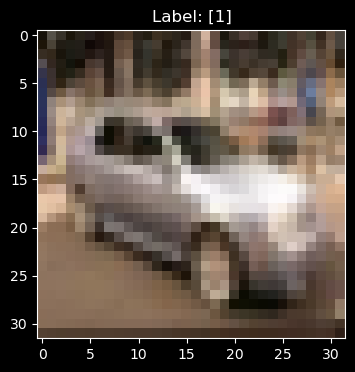

In [54]:
# Display a random image
idx = np.random.randint(0, len(X_train))
plt.figure(figsize=(4, 4))
plt.imshow(X_train[idx])
plt.title(f"Label: {y_train[idx]}")
plt.show()

In [55]:
import tensorflow as tf

# Resize and preprocess the data to match EfficientNetB3 input
X_train = np.array( tf.image.resize(X_train, (224, 224)) )
X_test = np.array( tf.image.resize(X_test, (224, 224)) )

print("X_train.shape:", X_train.shape)
print("X_test.shape: ", X_test.shape)

X_train.shape: (4000, 224, 224, 3)
X_test.shape:  (800, 224, 224, 3)


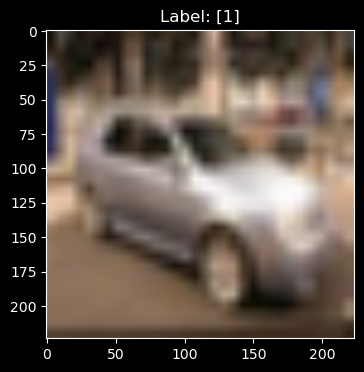

In [56]:
# Display a random image
plt.figure(figsize=(4, 4))
plt.imshow(X_train[idx].astype(int))
plt.title(f"Label: {y_train[idx]}")
plt.show()

# Modeling

## Load Pre-trained Model

Keras applications: https://keras.io/api/applications/

In [34]:
from tensorflow.keras.applications import EfficientNetV2M
from tensorflow.keras.applications import MobileNetV2

# Load EfficientNetB3 without top layer
#base_model = EfficientNetV2M(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
base_model = MobileNetV2(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
base_model.trainable = False

# Display model summary
#base_model.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


## Get pre-trained features

In [57]:
# Extract features using the pre-trained model
X_train_encoded = base_model.predict(X_train, verbose=1)
X_test_encoded = base_model.predict(X_test, verbose=1)

print("X_train_encoded.shape:", X_train_encoded.shape)
print("X_test_encoded.shape: ", X_test_encoded.shape)

125/125 ━━━━━━━━━━━━━━━━━━━━ 31s 250ms/step
25/25 ━━━━━━━━━━━━━━━━━━━━ 6s 253ms/step
X_train_encoded.shape: (4000, 7, 7, 1280)
X_test_encoded.shape:  (800, 7, 7, 1280)


## Create / train simple dense head

In [58]:
from tensorflow.keras.models import Model
from tensorflow.keras.layers import *

n_classes  = np.unique(y_train).shape[0]

# Create a classification head
input_encoded = Input(shape=X_train_encoded.shape[1:])
x = Flatten()(input_encoded)
x = Dropout(0.5)(x)
outputs = Dense(n_classes, activation='softmax')(x)

# Build the model
model = Model(inputs=input_encoded, outputs=outputs)

model.summary()

Model: "functional_9"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer_12 (InputLayer)          │ (None, 7, 7, 1280)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_9 (Flatten)                  │ (None, 62720)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_10 (Dropout)                 │ (None, 62720)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_11 (Dense)                     │ (None, 4)                   │         250,884 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 250,884 (980.02 KB)

 Trainable params: 250,884 (980.02 KB)

 Non-trainable params: 0 (0.00 B)

In [59]:
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers.schedules import ExponentialDecay, PolynomialDecay

# define training parameters
epochs     = 50
batch_size = 200

optimizer = Adam(
    learning_rate=0.001,
)

# Compile model
model.compile(
    optimizer=optimizer,
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Early stopping callback
early_stopping = EarlyStopping(
    monitor='val_loss',  # Monitor validation loss
    patience=20,          # Stop after 5 epochs without improvement
    restore_best_weights=True  # Restore the best weights after stopping
)

In [60]:
history = model.fit(
    X_train_encoded, y_train,
    epochs=epochs,
    batch_size=batch_size,
    shuffle=True,
    validation_data=(X_test_encoded, y_test),
    verbose=1,
    callbacks=[early_stopping]
)

Epoch 1/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - accuracy: 0.3564 - loss: 9.5609 - val_accuracy: 0.5813 - val_loss: 3.3284
Epoch 2/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - accuracy: 0.6429 - loss: 2.5388 - val_accuracy: 0.7113 - val_loss: 1.4885
Epoch 3/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - accuracy: 0.7593 - loss: 1.0265 - val_accuracy: 0.7300 - val_loss: 0.9997
Epoch 4/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - accuracy: 0.8044 - loss: 0.6689 - val_accuracy: 0.7275 - val_loss: 1.0401
Epoch 5/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - accuracy: 0.8306 - loss: 0.4994 - val_accuracy: 0.7425 - val_loss: 0.9303
Epoch 6/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - accuracy: 0.8755 - loss: 0.3428 - val_accuracy: 0.7350 - val_loss: 0.8817
Epoch 7/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - accuracy: 0.9029 - loss: 0.2730 - val_accuracy: 0.7325 - val_loss: 0.9240
Epoch 8/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - accuracy: 0.9079 - loss: 0.2423 - val_accuracy: 0.7300 - v

25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 


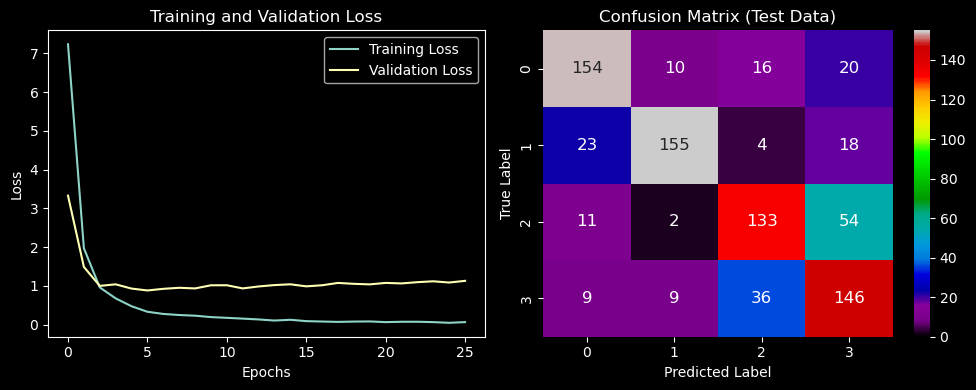

              precision    recall  f1-score   support

           0       0.78      0.77      0.78       200
           1       0.88      0.78      0.82       200
           2       0.70      0.67      0.68       200
           3       0.61      0.73      0.67       200

    accuracy                           0.73       800
   macro avg       0.74      0.73      0.74       800
weighted avg       0.74      0.73      0.74       800



In [61]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

# Get predictions
y_test_pred  = model.predict(X_test_encoded).argmax(axis=1)

# Create a figure with two subplots side by side
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# Left subplot: Training and Validation Loss
axes[0].plot(history.history['loss'], label='Training Loss')
axes[0].plot(history.history['val_loss'], label='Validation Loss')
#axes[0].set_yscale('log')
axes[0].set_title('Training and Validation Loss')
axes[0].set_xlabel('Epochs')
axes[0].set_ylabel('Loss')
axes[0].legend()

# Right subplot: Confusion Matrix (Test Data) using seaborn heatmap with vmin set to 0
cm = confusion_matrix(y_test, y_test_pred)
sns.heatmap(cm, annot=True, fmt='d', ax=axes[1], vmin=0, 
            annot_kws={"size": 12}, cmap='nipy_spectral')
axes[1].set_title('Confusion Matrix (Test Data)')
axes[1].set_xlabel('Predicted Label')
axes[1].set_ylabel('True Label')

plt.tight_layout()
plt.show()

# Print classification report for test data
report = classification_report(y_test, y_test_pred)
print(report)

## Create combined model

In [62]:
# Define the new input and pass through base_model
combined_input = Input(shape=(224, 224, 3))

x = base_model(combined_input, training=False)

# Now attach the existing classification head
x = model(x)

# Final combined model
combined_model = Model(inputs=combined_input, outputs=x)
combined_model.summary()

Model: "functional_10"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer_13 (InputLayer)          │ (None, 224, 224, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ mobilenetv2_1.00_224 (Functional)    │ (None, 7, 7, 1280)          │       2,257,984 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ functional_9 (Functional)            │ (None, 4)                   │         250,884 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 2,508,868 (9.57 MB)

 Trainable params: 250,884 (980.02 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [63]:
np.argmax(combined_model.predict(X_train[:10], verbose=1), axis=1)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 920ms/step


array([0, 0, 0, 0, 0, 2, 0, 2, 0, 0], dtype=int64)

In [64]:
y_train[:10]

array([[0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0]], dtype=uint8)